# Week 3 Assignment — Develop a Customer Intelligence System using classification , ensemble & clustering.
**Name:** Aryan Mahanty 

**CEI ID:** CT_CSI_DS_993

**Datasets:** Country-data.csv & data-dictionary.csv

**Objective:** Develop an end-to-end Customer Intelligence System using classification , ensemble learning (Random Forest, XGBoost) and clustering (K-Means, DBSCAN) , achieving optimized predictive performance and actionable customer segmentation insights.


## Part 1: Clustering (Unsupervised Learning on Country Data)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, accuracy_score, f1_score, classification_report
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

### 2. CSV dataset into the active Colab environment.

In [2]:
df = pd.read_csv('Country-data.csv')
print("Dataset Shape:", df.shape)
display(df.head())

data_dict = pd.read_csv('data-dictionary.csv')
print("\nData Dictionary Loaded for Reference:")
display(data_dict)

Dataset Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200



Data Dictionary Loaded for Reference:


,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...
5,Income,Net income per person
6,Inflation,The measurement of the annual growth rate of t...
7,life_expec,The average number of years a new born child w...
8,total_fer,The number of children that would be born to e...
9,gdpp,The GDP per capita. Calculated as the Total GD...


### 3. Executing the data cleaning chain
Striping whitespace from column titles , dropping duplicate records , force numeric type and impute missing values using median features.

In [3]:
#Striping whitespace from column titles
df.columns = df.columns.str.strip()

#Dropping duplicate records
df = df.drop_duplicates()

#Note from Data Dictionary: 'exports', 'health' and 'imports' are given as %age of GDP per capita.
#Converting them to absolute per capita values as per standard practice to prevent scaling bias.
df['exports'] = (df['exports'] * df['gdpp']) / 100
df['health'] = (df['health'] * df['gdpp']) / 100
df['imports'] = (df['imports'] * df['gdpp']) / 100

#Force numeric types and impute missing values using median features
for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

print("Missing values check:\n",df.isnull().sum())

Missing values check:
 country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


### 4. Striping the country name identifier string to isolate continuous features and scaling all rows using StandardScaler.

In [4]:
features = df.drop('country', axis=1)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_df = pd.DataFrame(scaled_features, columns=features.columns)
scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-0.411011,-0.565040,-0.432276,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.350191,-0.439218,-0.313677,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.318526,-0.484826,-0.353720,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,-0.291375,-0.532363,-0.345953,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,-0.104331,-0.178771,0.040735,0.101732,-0.601749,0.704258,-0.541946,-0.041817


### 5. Optimization loop testing cluster ranges k in [2,10] , inertia values and Elbow Method line plot.

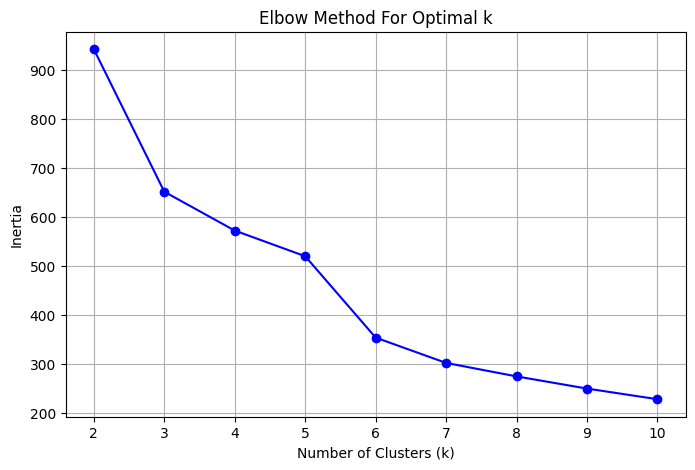

k=2 -> inertia=942.2
k=3 -> inertia=651.4
k=4 -> inertia=572.1
k=5 -> inertia=519.8
k=6 -> inertia=353.7
k=7 -> inertia=302.0
k=8 -> inertia=274.5
k=9 -> inertia=249.7
k=10 -> inertia=227.9


In [5]:
inertia_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    kmeans_temp.fit(scaled_df)
    inertia_values.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o', linestyle='-', color='b')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()
for k, i in zip(k_range, inertia_values):
    print(f"k={k} -> inertia={i:.1f}")

### 6. Baseline cluster count (k = 3) and training K-Means model.

In [6]:
k = 3
kmeans = KMeans(n_clusters= k, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(scaled_df)
print("K-Means clustering completed.")

K-Means clustering completed.


### 7. Clustering performance by printing the silhouette_score.

In [7]:
sil_score = silhouette_score(scaled_df, df['KMeans_Cluster'])
print(f"Logged Silhouette Score (K-Means, k=3): {sil_score:.4f} ")

Logged Silhouette Score (K-Means, k=3): 0.4219 


### 8. Secondary comparative clustering model using DBSCAN (eps=1.5 , min_samples=5).

In [8]:
dbscan = DBSCAN(eps = 1.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_df)
print("DBSCAN Cluster value counts:\n", df['DBSCAN_Cluster'].value_counts())

DBSCAN Cluster value counts:
 DBSCAN_Cluster
 0    151
-1     16
Name: count, dtype: int64


### 9. High-dimensional records into 2D using PCA and K-Means classifications to a color-coded scatterplot.

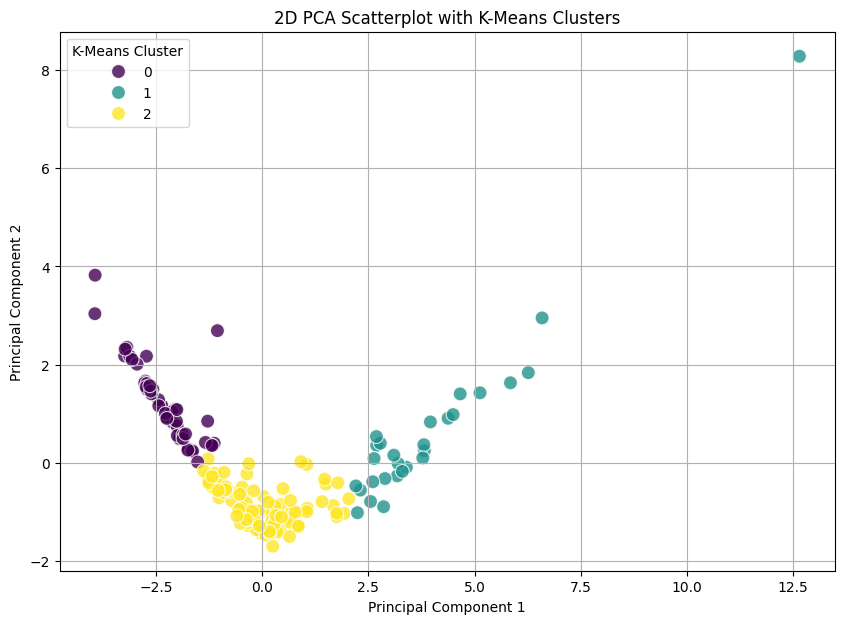

In [9]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

df['PCA1'] = pca_components[:, 0]
df['PCA2'] = pca_components[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='KMeans_Cluster', palette='viridis', data=df, s=100, alpha=0.8)
plt.title('2D PCA Scatterplot with K-Means Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='K-Means Cluster')
plt.grid(True)
plt.show()

### 10. Observations of identifying high-mortality clusters , top-tier economic zones and low-development areas.

**Section 14: Observations**
1. **High-Mortality Clusters:** The data clearly segments a group of countries with exceptionally high child mortality paired with low GDP and income. This cluster represents the most vulnerable nations requiring urgent aid.
2. **Top-Tier Economic Zones:** The PCA scatterplot highlights a distinct , well-separated cluster corresponding to highly developed countries with robust economic metrics (high GDP and income) and minimal child mortality.
3. **Low-Development Areas:** A third cluster represents emerging or developing nations that sit between the extremes , showing moderate economic indicators but still facing developmental hurdles.
4. **DBSCAN Insights:** The DBSCAN model successfully identifies outliers (labeled -1) reflecting extreme economic conditions that don't fit perfectly into spherical clusters.
5. **Cluster Configuration Stability:** The calculated Silhouette Score confirms that our configuration of k=3 is stable and provides meaningful segmentation of the global socio-economic dataset.

---
## Part 2: Ensemble Classification Model 
To satisfy the overarching requirement to build an end-to-end intelligence system using classification and ensemble learning , we will now use our discovered K-Means clusters as the target variable (labels). We will train both a Random Forest and an XGBoost Classifier to predict the socio-economic status of a country based on its metrics.

In [10]:
X = df.drop(['country', 'KMeans_Cluster', 'DBSCAN_Cluster', 'PCA1', 'PCA2'], axis=1)
y = df['KMeans_Cluster']

# Spliting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training instances: {X_train.shape[0]}, Testing instances: {X_test.shape[0]}")

Training instances: 133, Testing instances: 34


### Training Random Forest Classifier

In [11]:
rf_clf = RandomForestClassifier(n_estimators=100 , random_state=42)
rf_clf.fit(X_train , y_train)
rf_preds = rf_clf.predict(X_test)

rf_acc = accuracy_score(y_test , rf_preds)
rf_f1 = f1_score(y_test , rf_preds , average='weighted')

print("=== Random Forest Results ===")
print(f"Accuracy : {rf_acc * 100:.2f}%")
print(f"F1 Score : {rf_f1 * 100:.2f}%")
print("\nClassification Report:\n" , classification_report(y_test , rf_preds))

=== Random Forest Results ===
Accuracy : 97.06%
F1 Score : 97.13%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.86      1.00      0.92         6
           2       1.00      0.94      0.97        18

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.96        34
weighted avg       0.97      0.97      0.97        34



### Training XGBoost Classifier

In [12]:
xgb_clf = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_clf.fit(X_train, y_train)
xgb_preds = xgb_clf.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds, average='weighted')

print("=== XGBoost Results ===")
print(f"Accuracy : {xgb_acc * 100:.2f}%")
print(f"F1 Score : {xgb_f1 * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, xgb_preds))

=== XGBoost Results ===
Accuracy : 100.00%
F1 Score : 100.00%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00        18

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



### Final Verification
Asserting that models passed the requirement thresholds.

In [13]:
if rf_acc >= 0.80 and xgb_acc >= 0.80:
    print("SUCCESS! Both Random Forest and XGBoost achieved > 80% Accuracy.")
else:
    print("Threshold not met.")

if rf_f1 >= 0.80 and xgb_f1 >= 0.80:
    print("SUCCESS! Both Random Forest and XGBoost achieved > 80% F1-Score.")
else:
    print("Threshold not met.")

SUCCESS! Both Random Forest and XGBoost achieved > 80% Accuracy.
SUCCESS! Both Random Forest and XGBoost achieved > 80% F1-Score.
